In [7]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

In [12]:
RUN_DIR = (
    Path.home()
    / "Desktop"
    / "hep_ssl_KunheLi"
    / "hep-ssl"
    / "chtc"
    / "2026_08_02"
)

OUTPUT_DIR = (
    Path.home()
    / "Desktop"
    / "hep_ssl_KunheLi"
    / "hep-ssl"
    / "analysis"
    / "pretraining_loss"
    / "individual_curves"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

log_files = sorted(
    RUN_DIR.glob("sweep_5969386_*.out")
)

print("Number of log files:", len(log_files))

Number of log files: 10


In [13]:
epoch_pattern = re.compile(
    r"Epoch\s+(\d+)/\d+"
    r"\s+\|\s+train_loss=([0-9.eE+-]+)"
    r"\s+\|\s+val_loss=([0-9.eE+-]+)"
)

records = []
experiment_order = []

for log_file in log_files:
    experiment = re.sub(
        r"sweep_\d+_\d+_",
        "",
        log_file.stem,
    )

    experiment_order.append(experiment)

    text = log_file.read_text(
        encoding="utf-8",
        errors="replace",
    )

    for match in epoch_pattern.finditer(text):
        records.append(
            {
                "experiment": experiment,
                "epoch": int(match.group(1)),
                "train_loss": float(match.group(2)),
                "val_loss": float(match.group(3)),
            }
        )

loss_df = pd.DataFrame(records)

loss_df

,experiment,epoch,train_loss,val_loss
0,baseline,1,2.274070,1.505304
1,baseline,2,1.498247,1.194588
2,baseline,3,1.205907,1.130606
3,baseline,4,1.034623,0.931167
4,baseline,5,0.966808,0.838316
...,...,...,...,...
175,shift_then_rotate,14,0.595244,0.564984
176,shift_then_rotate,15,0.564846,0.558405
177,shift_then_rotate,16,0.566800,0.540895
178,shift_then_rotate,17,0.560926,0.537732


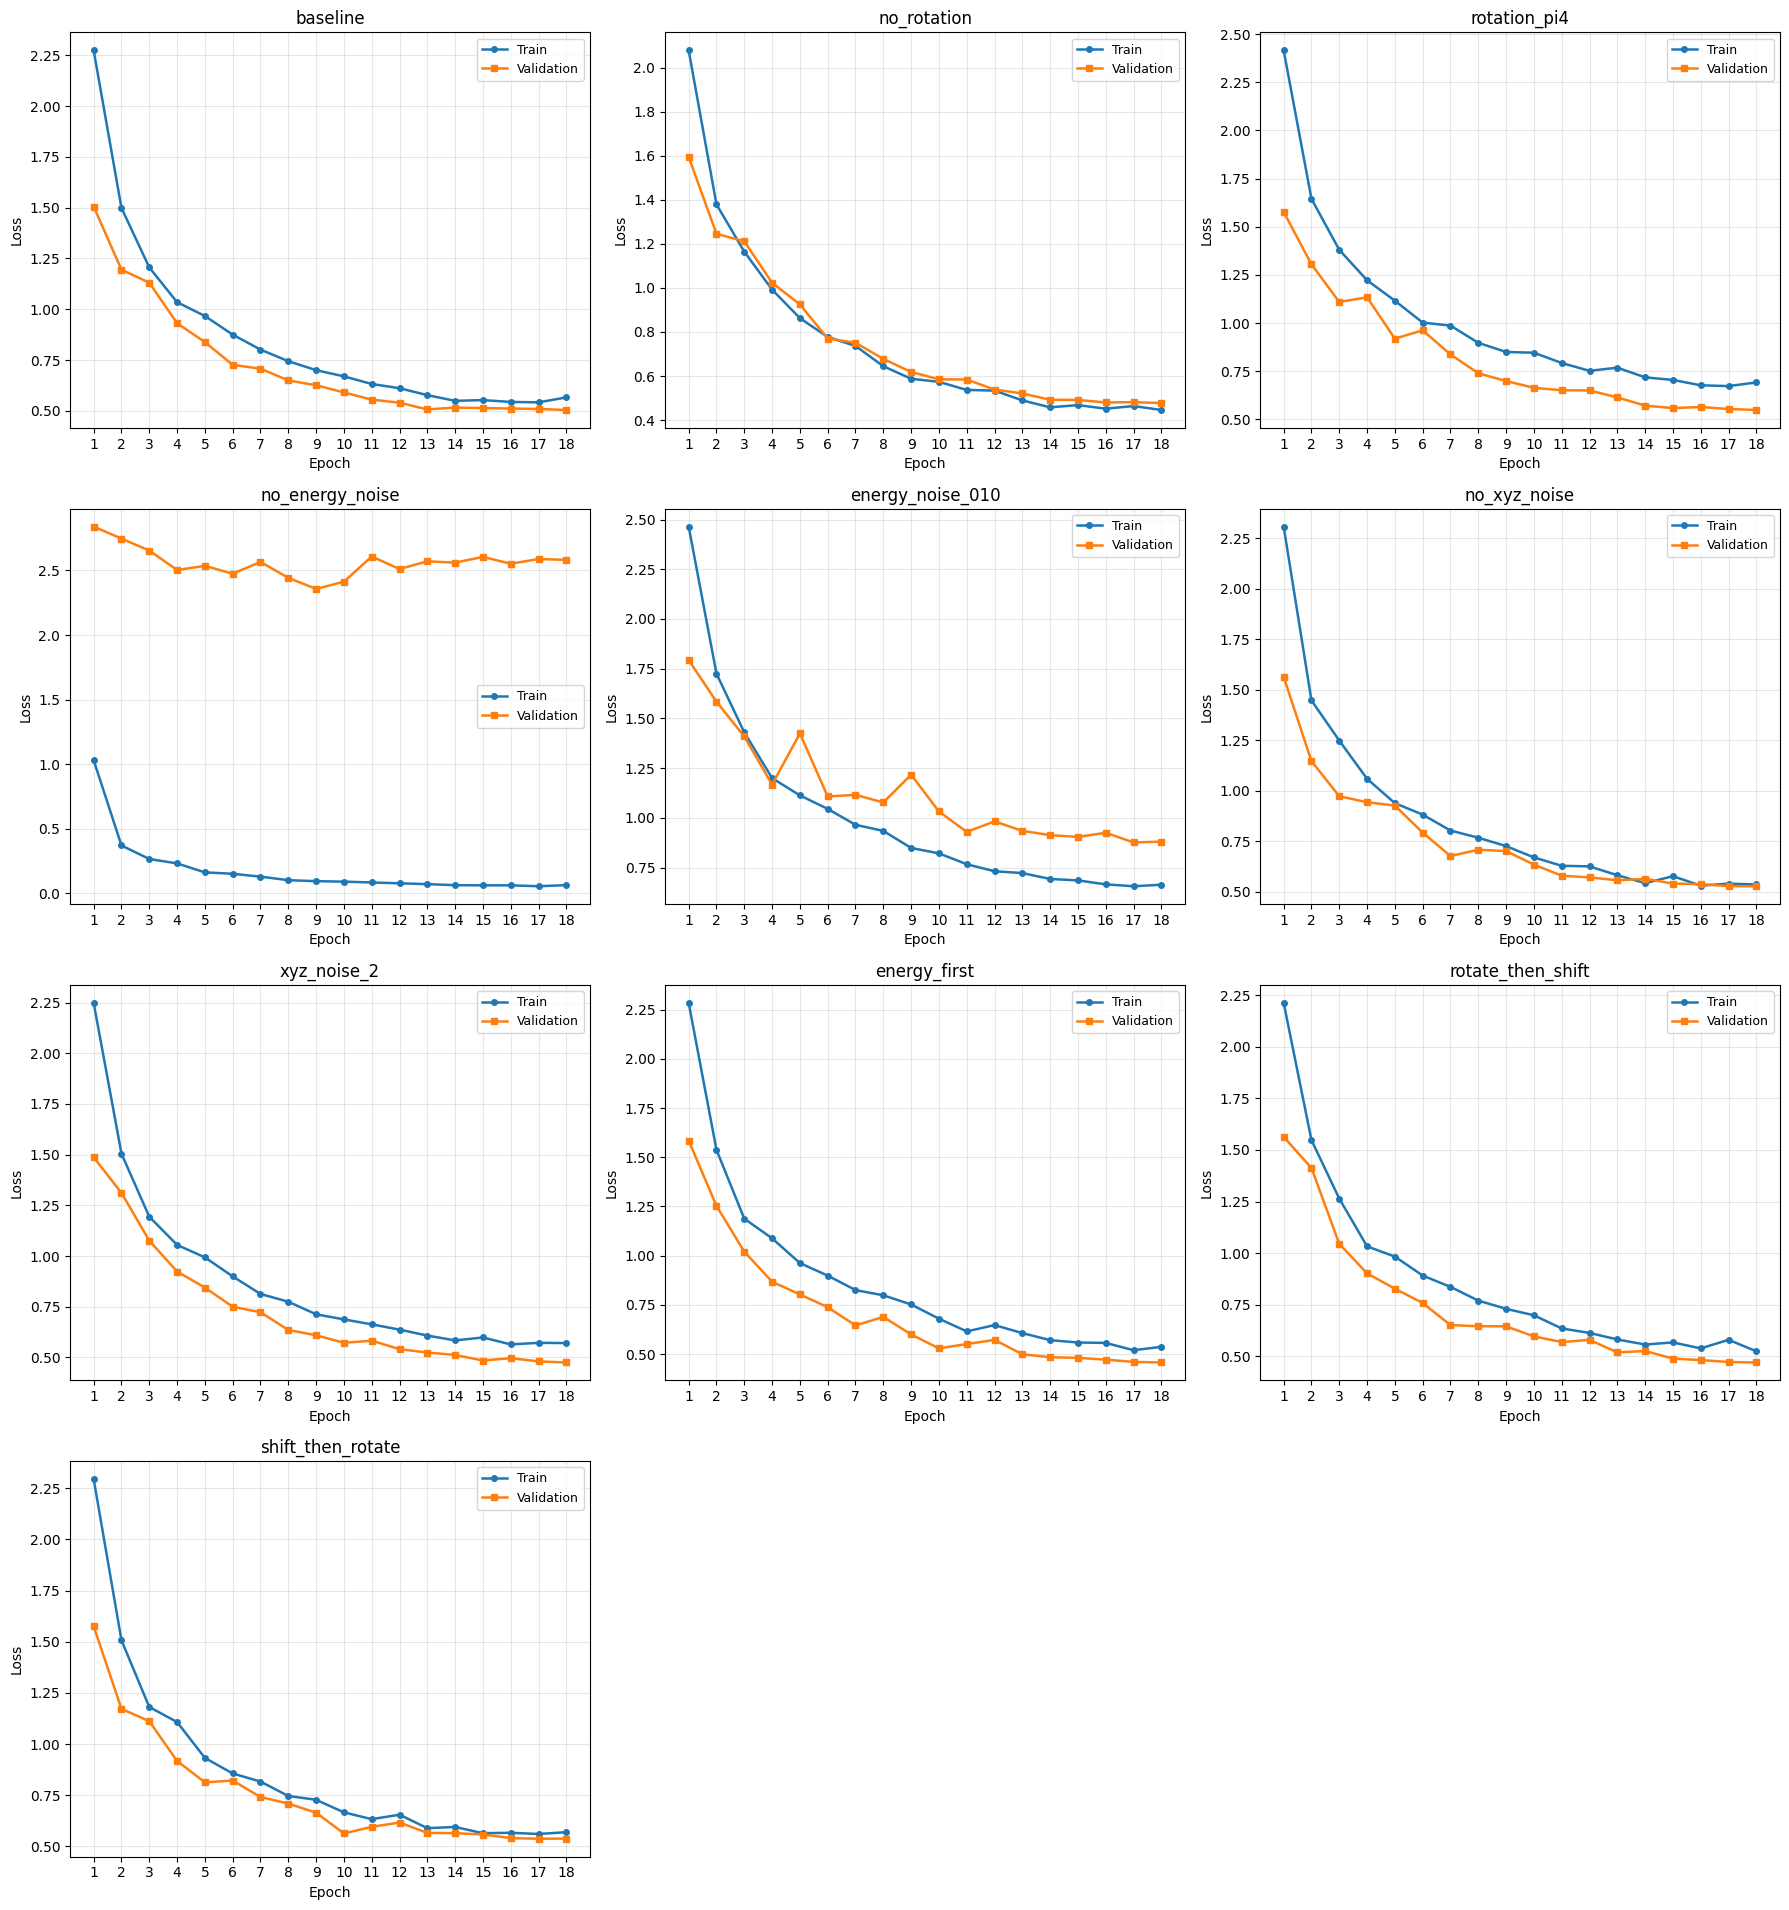

Saved to: /Users/clintli/Desktop/hep_ssl_KunheLi/hep-ssl/analysis/pretraining_loss/individual_curves/all_loss_curves_grid.png


In [15]:
import math

experiments = experiment_order
n_experiments = len(experiments)
ncols = 3
nrows = math.ceil(n_experiments / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 4.8 * nrows)
)

axes = axes.flatten()

for i, experiment in enumerate(experiments):
    ax = axes[i]

    experiment_df = loss_df[
        loss_df["experiment"] == experiment
    ]

    ax.plot(
        experiment_df["epoch"],
        experiment_df["train_loss"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        label="Train"
    )

    ax.plot(
        experiment_df["epoch"],
        experiment_df["val_loss"],
        marker="s",
        markersize=4,
        linewidth=1.8,
        label="Validation"
    )

    ax.set_title(experiment, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(range(1, 19))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# 把多出来的空白子图关掉
for j in range(n_experiments, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

output_path = OUTPUT_DIR / "all_loss_curves_grid.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()
print(f"Saved to: {output_path}")